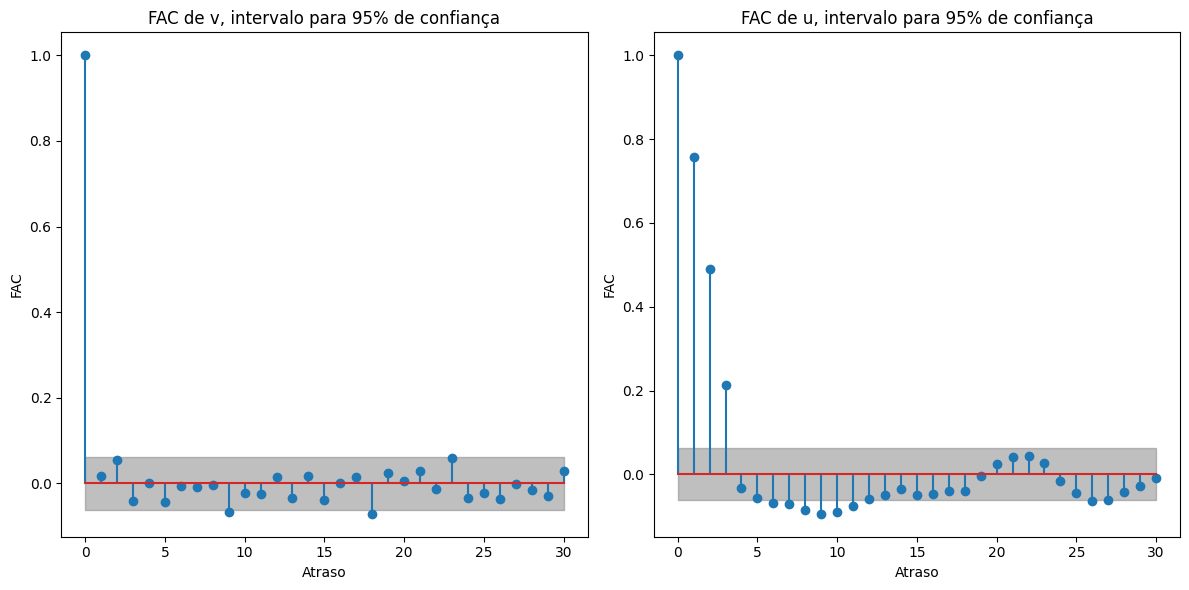

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, ccf, acovf, ccovf

# Define the signal u[k] = 0.9v[k-1] + 0.8v[k-2] + 0.7v[k-3] + v[k]
def u_func(k, v):
    return 0.9 * v[k-1] + 0.8 * v[k-2] + 0.7 * v[k-3] + v[k]

n_samples = 1000

# Initialize the input white noise
v = np.random.normal(0, 1, n_samples)

# Initialize the signal
u_signal = np.zeros(n_samples)

# Compute the signal u
for k in range(3, n_samples):
    u_signal[k] = u_func(k, v)

# Compute ACF for both v and u_signal
acf_v = acf(v)
acf_u = acf(u_signal)

# Compute the 95% confidence intervals
conf_int_v = 1.96 / np.sqrt(n_samples)
conf_int_u = 1.96 / np.sqrt(n_samples)

# Plot ACF and confidence intervals
plt.figure(figsize=(12, 6))

# ACF for v
plt.subplot(1, 2, 1)
plt.stem(acf_v)
plt.fill_between(np.arange(len(acf_v)), -conf_int_v, conf_int_v, color='gray', alpha=0.5)
plt.title('FAC de v, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

# ACF for u_signal
plt.subplot(1, 2, 2)
plt.stem(acf_u)
plt.fill_between(np.arange(len(acf_u)), -conf_int_u, conf_int_u, color='gray', alpha=0.5)
plt.title('FAC de u, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

plt.tight_layout()
plt.show()

A FAC de `v` condiz com o esperado, valor estatisticamente significante somente para $\tau=0$. Esta curca é característica de sinais brancos, para os quais `v[k]` não é função alguma de `v[k-1]`. Para `u`, a FAC também é coerente com a expressão matemárica. Apesar de `u[k]` não ser função de `u[k-1]`, dois de seus três termos tomam valores comuns de `u`:

\begin{align*}
u[k-1] = &0.9v[k-2] + 0.8v[k-3] + 0.7[k-4] + v[k-1] \\
u[k] = 0.9v[k-1] + &0.8v[k-2] + 0.7v[k-3] + v[k]
\end{align*}

Assim, mesmo que `u[k]` não seja efeito de `u[k-1]`, estes compartilham parte da causa, o que explica o decaimento suave da função de auto correlação.

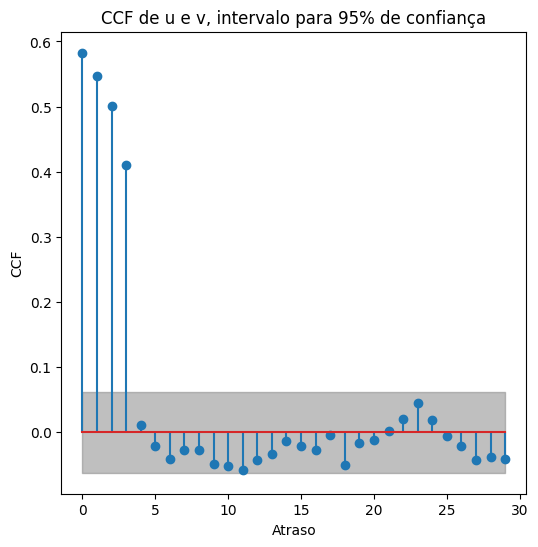

In [45]:
ccf_uv = ccf(u_signal, v, nlags=30)

# Compute the 95% confidence intervals
conf_int_uv = 1.96 / np.sqrt(n_samples)

# Plot CCF and confidence intervals
plt.figure(figsize=(6, 6))
plt.stem(ccf_uv)
plt.fill_between(np.arange(len(ccf_uv)), -conf_int_uv, conf_int_uv, color='gray', alpha=0.5)
plt.title('CCF de u e v, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

Já neste caso, a correlação alta para os primeiros intervalos se dá pelo fato de `u` ser função de `v`. Novamente, o decaimento suavizado nos primeiros atrasos decorre do comportamento passa baixas do sinal, definido por três valores consecultivos de `v`. É interessante notar que o decaimento repentino na correlação após $\tau = 3$ é coerente com a definição do sinal: como não há recursividade neste sistema, não é esperada correlação entre `u[k]` e `u[k-4]`.

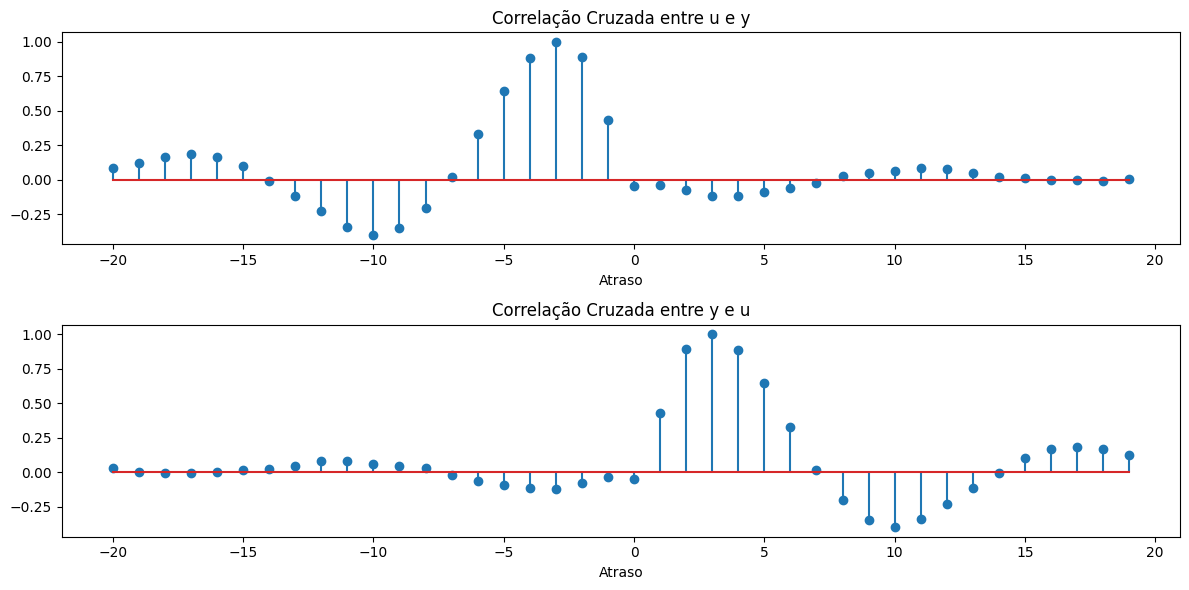

In [46]:
import scipy.signal as signal

# Define the transfer function H(z) = (z + 0.5) / (z^2 - 1.5z + 0.7)
num = [1, 0.5]
den = [1, -1.5, 0.7]
Ts = 1 # 1 second

# Define the input signal
u = np.random.uniform(-1, 1, n_samples)

# Simulate the system's response to u
t, y = signal.dlsim((num, den, Ts), u)
y = y.flatten()  # Flatten the output to 1D array

# Compute the CCF in both ways
ccf_uy = signal.correlate(u, y)
ccf_yu = signal.correlate(y, u)

# Normalize the CCFs
ccf_uy /= np.max(np.abs(ccf_uy))
ccf_yu /= np.max(np.abs(ccf_yu))

# Create lag vector for the full cross-correlation result
n = len(u)
lags = np.arange(-n + 1, n)

# Set plot interval
interval = (len(lags)//2)-20, (len(lags)//2)+20

# Plot the CCFs
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.title('Correlação Cruzada entre u e y')
plt.stem(lags[interval[0]:interval[1]], ccf_uy[interval[0]:interval[1]])  # Centered around zero lag
plt.xlabel('Atraso')

plt.subplot(2, 1, 2)
plt.title('Correlação Cruzada entre y e u')
plt.stem(lags[interval[0]:interval[1]], ccf_yu[interval[0]:interval[1]])  # Centered around zero lag
plt.xlabel('Atraso')

plt.tight_layout()
plt.show()


As curvas traçadas indicam que, quando a ordem dos parâmetros na chamada da função é `saída, entrada`, a correlação é mais significativa para atrasos positivos.

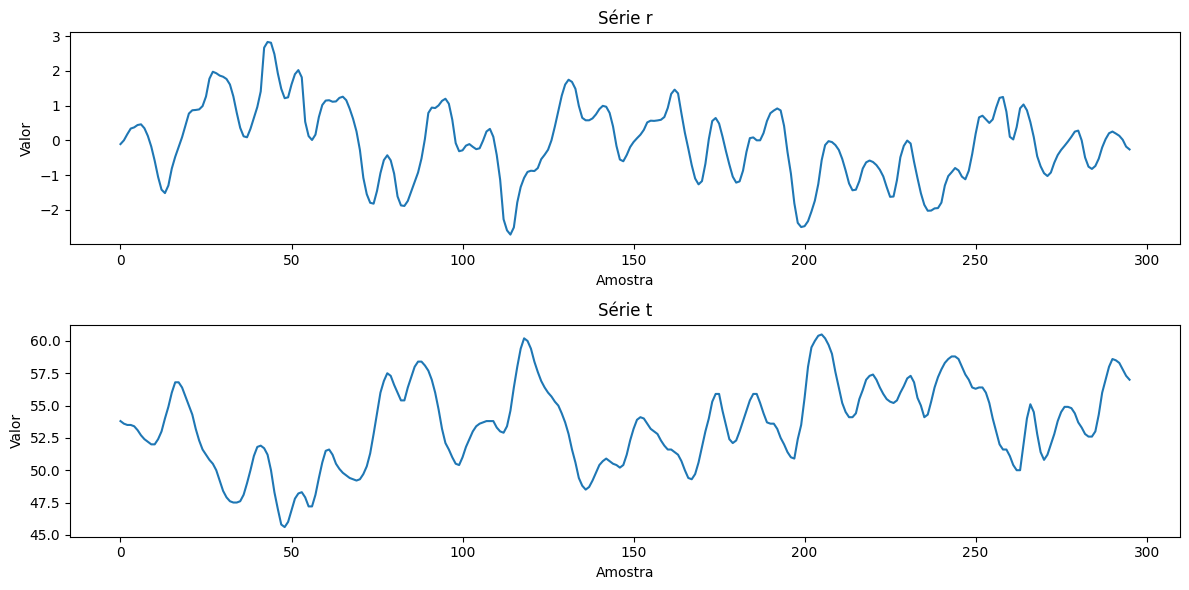

In [47]:
# Load the two-column data file into arrays
box = np.loadtxt('boxjenk.dat')
r, t = box[:, 0], box[:, 1]

# Plot the raw data
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(r)
plt.title('Série r')
plt.xlabel('Amostra')
plt.ylabel('Valor')
plt.subplot(2, 1, 2)
plt.plot(t)
plt.title('Série t')
plt.xlabel('Amostra')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()

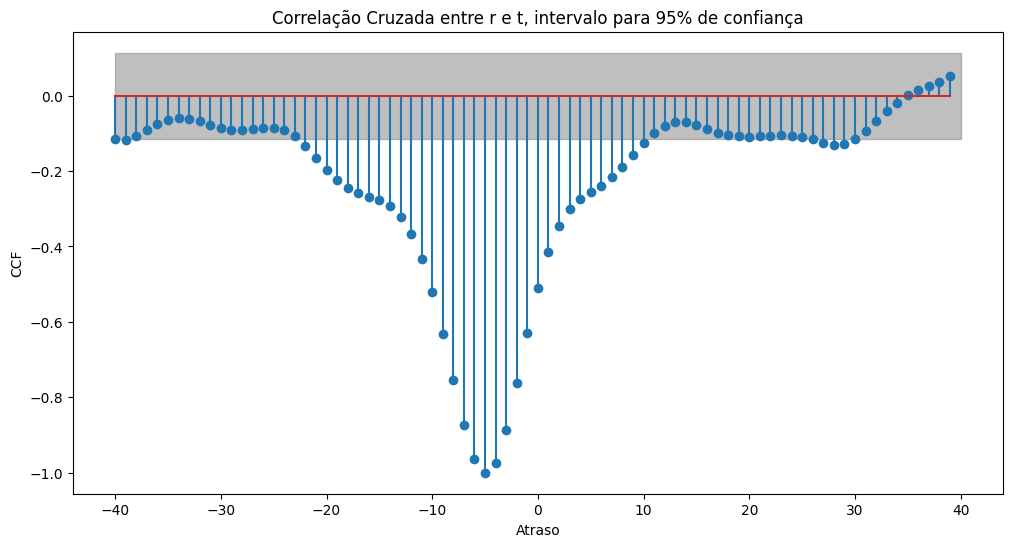

In [48]:
# Center the data by removing the mean
r, t = r - np.mean(r), t - np.mean(t)

# Compute CCF between r and t
ccf_rt = signal.correlate(r, t)

# Compute the 95% confidence intervals
conf_int_rt = 1.96 / np.sqrt(len(r))

# Normalize the CCF
ccf_rt /= np.max(np.abs(ccf_rt))

# Create lag vector for the full cross-correlation result
n = len(r)
lags = np.arange(-n + 1, n)

# Set plot interval
interval = (len(lags)//2)-40, (len(lags)//2)+40

# Plot the CCF with confidence intervals
plt.figure(figsize=(12, 6))
plt.stem(lags[interval[0]:interval[1]], ccf_rt[interval[0]:interval[1]])  # Centered around zero lag
plt.fill_between(np.arange(-40, 41), -conf_int_rt, conf_int_rt, color='gray', alpha=0.5)
plt.title('Correlação Cruzada entre r e t, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

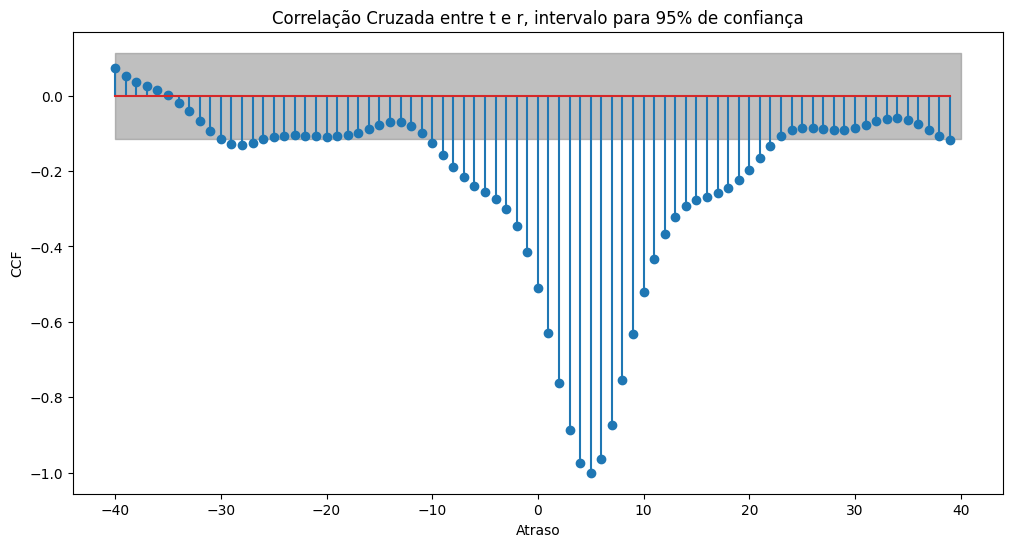

In [49]:
# Compute the CCF between t and r
ccf_tr = signal.correlate(t, r)

# Normalize the CCF
ccf_tr /= np.max(np.abs(ccf_tr))

# Plot the CCF with confidence intervals
plt.figure(figsize=(12, 6))
plt.stem(lags[interval[0]:interval[1]], ccf_tr[interval[0]:interval[1]])  # Centered around zero lag
plt.fill_between(np.arange(-40, 41), -conf_int_rt, conf_int_rt, color='gray', alpha=0.5)
plt.title('Correlação Cruzada entre t e r, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('CCF')
plt.show()

As curvas indicam que `t` e `r` são, respectivamente, saída e entrada.

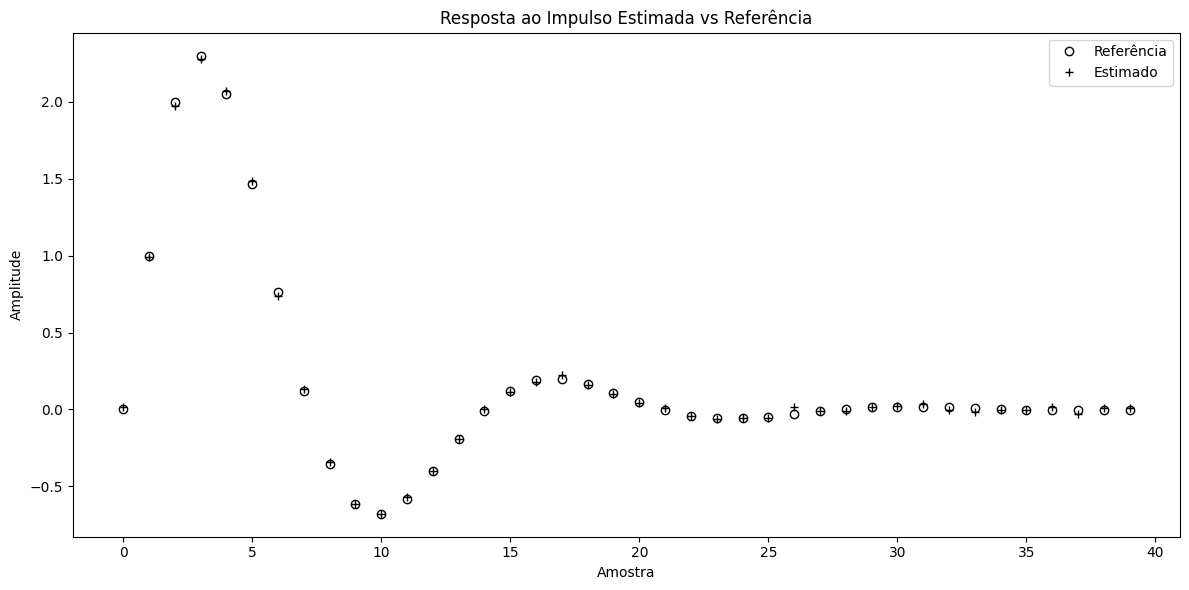

In [50]:
from scipy.linalg import toeplitz

# Define the transfer function H(z) = (z + 0.5) / (z^2 - 1.5z + 0.7)
num = [1, 0.5]
den = [1, -1.5, 0.7]
Ts = 1  # 1 second

# Excite with white input
u = np.random.uniform(-1, 1, n_samples)

# Simulate the system's response to u
t, y = signal.dlsim((num, den, Ts), u)
y = y.flatten()

# Add noise to the output
ynoise_std = 0.1 * np.std(y)
y_noise = y + np.random.normal(0, ynoise_std, size=y.shape)

# Zero-mean signals for correlation estimation
u_zm = u - np.mean(u)
y_noise_zm = y_noise - np.mean(y_noise)

# Correlations and unbiased normalization
r_uu_full = signal.correlate(u_zm, u_zm)
r_yu_full = signal.correlate(y_noise_zm, u_zm)
n = len(u_zm)
zero_idx = n - 1

n_steps_to_estimate = 40
lags = np.arange(n_steps_to_estimate)
unbias = (n - lags).astype(float)

ru = r_uu_full[zero_idx + lags] / unbias  # r_u[k], k >= 0
ryu = r_yu_full[zero_idx + lags] / unbias # r_yu[k], k >= 0

# Toeplitz autocorrelation matrix Ru
Ru = toeplitz(ru)

# Tikhonov regularization for numerical stability / noise robustness
lam = 1e-2 * ru[0]
h = np.linalg.solve(Ru + lam * np.eye(n_steps_to_estimate), ryu)

# Reference impulse response
t_ref, h_ref = signal.dimpulse((num, den, Ts), n=n_steps_to_estimate)
h_ref = h_ref[0].flatten() if h_ref is not None else np.zeros(n_steps_to_estimate)

# Plot
plt.figure(figsize=(12, 6))
n = np.arange(n_steps_to_estimate)
plt.plot(n, h_ref, linestyle='None', marker='o', markeredgecolor='k', markerfacecolor='none', label='Referência')
plt.plot(n, h, linestyle='None', marker='+', color='k', label='Estimado')
plt.title('Resposta ao Impulso Estimada vs Referência')
plt.xlabel('Amostra')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

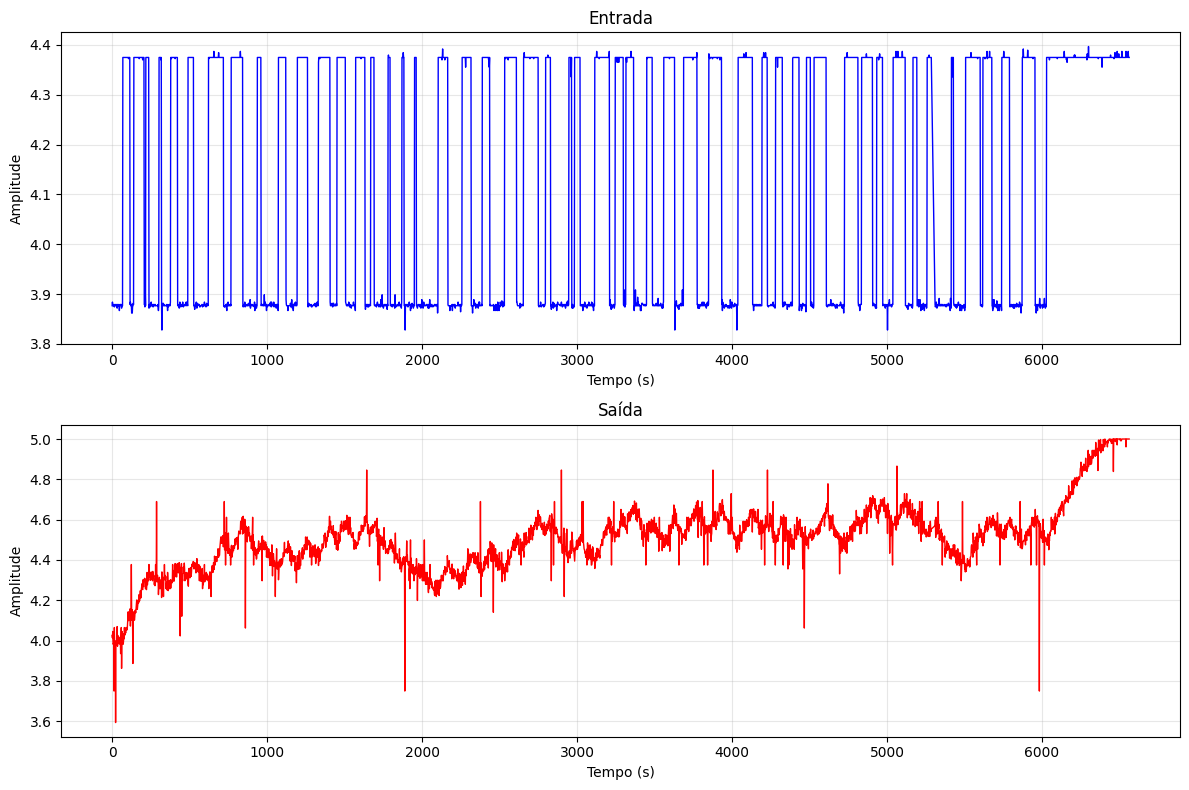

In [51]:
# Load the data from the file
data = np.loadtxt('prbsa02.dat')
time = data[:, 0]
input = data[:, 1]
output = data[:, 2]

# Plot input and output vs time
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(time, input, 'b-', linewidth=1)
plt.title('Entrada')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(time, output, 'r-', linewidth=1)
plt.title('Saída')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

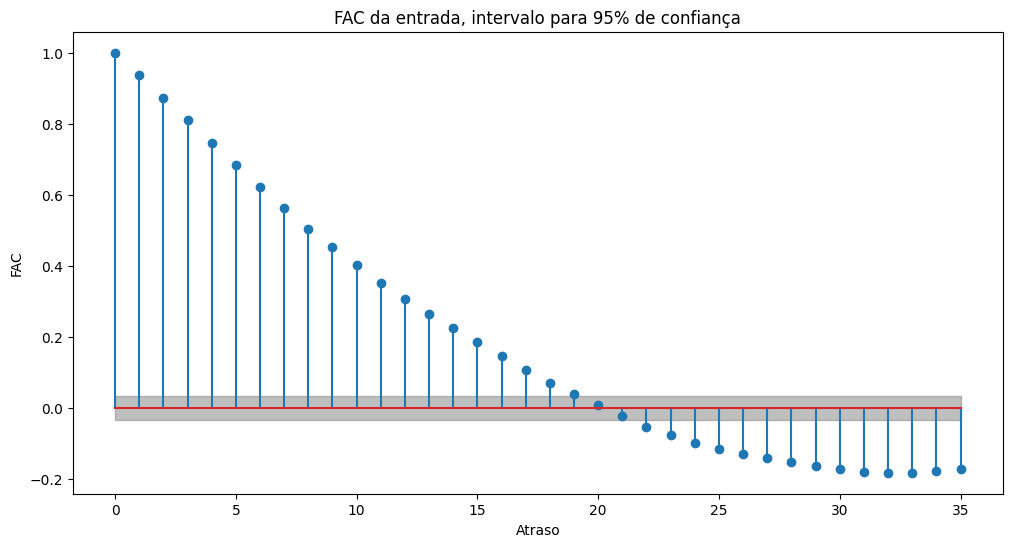

In [52]:
# ACF of unbiased input
x = input - np.mean(input)
n = len(x)
rx = acf(x)

# Confidence intervals
conf_int = 1.96 / np.sqrt(n)

# Plot ACF with confidence intervals
plt.figure(figsize=(12, 6))
plt.stem(rx)
plt.fill_between(np.arange(len(rx)), -conf_int, conf_int, color='gray', alpha=0.5)
plt.title('FAC da entrada, intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')
plt.show()

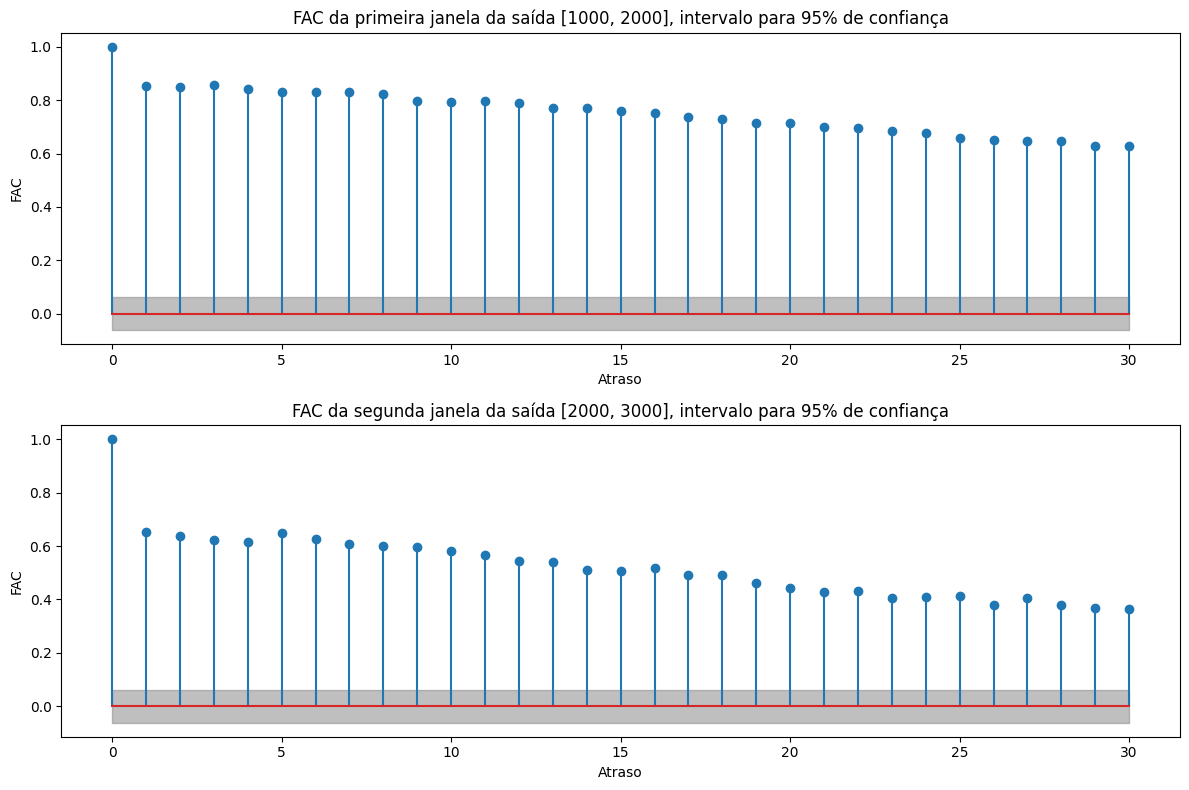

In [53]:
# Extract two windows of the output
output_first_window = output[1000:2000]
output_second_window = output[2000:3000]

# ACF of first window of output
y1 = output_first_window - np.mean(output_first_window)
n1 = len(y1)
ry1 = acf(y1)

# Confidence intervals
conf_int1 = 1.96 / np.sqrt(n1)

# ACF of second window of output
y2 = output_second_window - np.mean(output_second_window)
n2 = len(y2)
ry2 = acf(y2)

# Confidence intervals
conf_int2 = 1.96 / np.sqrt(n2)

# Plot both ACFs with confidence intervals as subplots
plt.figure(figsize=(12, 8))

# First subplot
plt.subplot(2, 1, 1)
plt.stem(ry1)
plt.fill_between(np.arange(len(ry1)), -conf_int1, conf_int1, color='gray', alpha=0.5)
plt.title('FAC da primeira janela da saída [1000, 2000], intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

# Second subplot
plt.subplot(2, 1, 2)
plt.stem(ry2)
plt.fill_between(np.arange(len(ry2)), -conf_int2, conf_int2, color='gray', alpha=0.5)
plt.title('FAC da segunda janela da saída [2000, 3000], intervalo para 95% de confiança')
plt.xlabel('Atraso')
plt.ylabel('FAC')

plt.tight_layout()
plt.show()

Em ambas as janelas, a função de autocorrelação apresenta valores estatisticamente significativos em ampla faixa de atrasos, evidenciando forte dependência temporal e memória típica de saídas de sistemas dinâmicos. Na segunda janela, há redução na magnitude da FAC, condizente com a remoção de segmentos corrompidos: a edição introduz quebras de estacionariedade e descontinuidades que degradam a estimativa correlacional, atenuando a recuperação da dinâmica do processo.